In [1]:
import pyreadr
import numpy as np
from scipy.stats import zscore
import torch
import mgplvm as mgp
import torch
import matplotlib.pyplot as plt
import pickle
import time

loading


In [2]:
from sklearn.decomposition import FactorAnalysis
from sklearn.linear_model import LinearRegression, Ridge
from scipy.interpolate import CubicSpline
from scipy.ndimage import gaussian_filter1d
plt.rcParams['font.size'] = 20
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
np.random.seed(0)
torch.manual_seed(0)
device = mgp.utils.get_device() # use GPU if available, otherwise CPU
print(device)
# -------------------------
# 1) Load RDS data
# -------------------------
result = pyreadr.read_r("GPFA_array_out_circle_NumTrials_x_Time45_x_Neurons.RDS")
r_object = next(iter(result.values()))

cpu


In [3]:
# Convert to NumPy array
Y = np.array(r_object, dtype=int)
print("Shape of Y:", Y.shape)  # (n_trials, T, n_neurons)

Shape of Y: (40, 45, 325)


In [4]:
# Sort dimensions: [trials, neurons, timepoints]
Y = np.transpose(Y, (0, 2, 1))
print("Shape Y after transpose:", Y.shape)  # (n_trials, neurons, T)

Shape Y after transpose: (40, 325, 45)


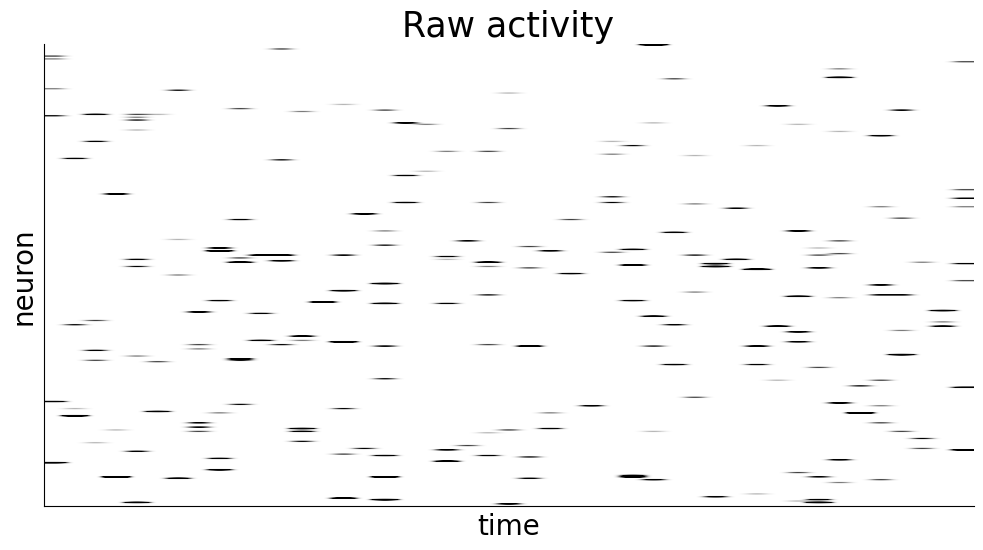

In [5]:

plt.figure(figsize = (12, 6))
plt.imshow(Y[0, ...], cmap = 'Greys', aspect = 'auto', vmin = np.quantile(Y, 0.01), vmax = np.quantile(Y, 0.99))
plt.xlabel('time')
plt.ylabel('neuron')
plt.title('Raw activity', fontsize = 25)
plt.xticks([])
plt.yticks([])
plt.show()




In [6]:
# Save shape
ntrials, n, T = Y.shape

# -------------------------
# 3) Setup device
# -------------------------
device = "gpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [7]:
### check ###
print("n:", n)  
print("ntrials:", ntrials)  
print("T:", T)  

n: 325
ntrials: 40
T: 45


In [8]:
# -------------------------
# 4) Define fit_ts for GP
# -------------------------
fit_ts = torch.arange(T, dtype=torch.float32)[None, None, :].to(device)  # shape [1,1,T]

# -------------------------
# 5) Parameters bGPFA
# -------------------------
d_fit = 10       # maximum number of latent dimensions
binsize = 66.67  # ms per bin   
ell0 = 100/binsize  # initial timescale for GP     
rho = 2          # relative scale for ARD


## set some parameters for fitting ###
max_steps = 2000 # number of training iterations
n_mc = 5 # number of monte carlo samples per iteration
print_every = 5 # how often we print training progress


In [9]:
# -------------------------
# 6) Build model
# -------------------------
lik = mgp.likelihoods.NegativeBinomial(n, Y=Y)

# manifold of latents
manif = mgp.manifolds.Euclid(T, d_fit)

# variational posterior GP (circulant)
var_dist = mgp.rdist.GP_circ(manif, T, ntrials, fit_ts, _scale=1, ell=ell0)

# prior latents (null)
lprior = mgp.lpriors.Null(manif)


In [10]:
# build bGPFA
mod = mgp.models.Lvgplvm(
    n=n,
    m=T,
    d=d_fit,
    n_samples=ntrials,
    lat_dist=var_dist,
    lprior=lprior,
    likelihood=lik,
    Y=Y,
    learn_scale=False,
    ard=True,
    rel_scale=rho
)

# move to GPU/CPU
mod = mod.to(device)

print("bGPFA model. Shape data:", Y.shape)

bGPFA model. Shape data: (40, 325, 45)


In [11]:

t0 = time.time()
def cb(mod, i, loss):
    """here we construct an (optional) function that helps us keep track of the training"""
    if i % print_every == 0:
        sd = np.log(mod.obs.dim_scale.detach().cpu().numpy().flatten())
        print('iter:', i, 'time:', str(round(time.time()-t0))+'s', 'log scales:', np.round(sd[np.argsort(-sd)], 1))

In [12]:
import torch 

Y_tensor = torch.tensor(Y, dtype=torch.float32)

train_ps = mgp.crossval.training_params(
    max_steps=max_steps, 
    n_mc=n_mc, 
    lrate=7.5e-2, 
    callback=cb, 
    print_every=np.nan
)

print('fitting', n, 'neurons and', T, 'time bins for', max_steps, 'iterations')

mod_train = mgp.crossval.train_model(mod, Y_tensor, train_ps)

fitting 325 neurons and 45 time bins for 4500 iterations
iter: 0 time: 3s log scales: [-2.  -2.1 -2.1 -2.1 -2.2 -2.2 -2.2 -2.2 -2.2 -2.3 -2.3 -2.3 -2.3 -2.3
 -2.3 -2.3 -2.3 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.5]
iter: 5 time: 15s log scales: [-2.  -2.1 -2.1 -2.1 -2.2 -2.2 -2.2 -2.2 -2.2 -2.3 -2.3 -2.3 -2.3 -2.3
 -2.3 -2.3 -2.3 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.5]
iter: 10 time: 27s log scales: [-2.  -2.1 -2.1 -2.1 -2.2 -2.2 -2.2 -2.2 -2.2 -2.3 -2.3 -2.3 -2.3 -2.3
 -2.3 -2.3 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.5 -2.5]
iter: 15 time: 39s log scales: [-2.  -2.1 -2.1 -2.2 -2.2 -2.2 -2.2 -2.2 -2.3 -2.3 -2.3 -2.3 -2.3 -2.3
 -2.3 -2.3 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.5 -2.5]
iter: 20 time: 51s log scales: [-2.  -2.1 -2.1 -2.2 -2.2 -2.2 -2.2 -2.2 -2.3 -2.3 -2.3 -2.3 -2.3 -2.3
 -2.3 -2.3 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.5 -2.5 -2.5]
iter: 25 time: 64s log scales: [-2.  -2.1 -2.1 -2.2 -2.2 -2.2 -2.2 -2.3 -2.3 -2.3 -2.3 -2.3 -2.3 -2.3
 -2.3 -2.3 -2.4 -2.4 -2.4 -2.4 -2.4 -2.4 -2.5 -2.

plotting informative and discarded dimensions


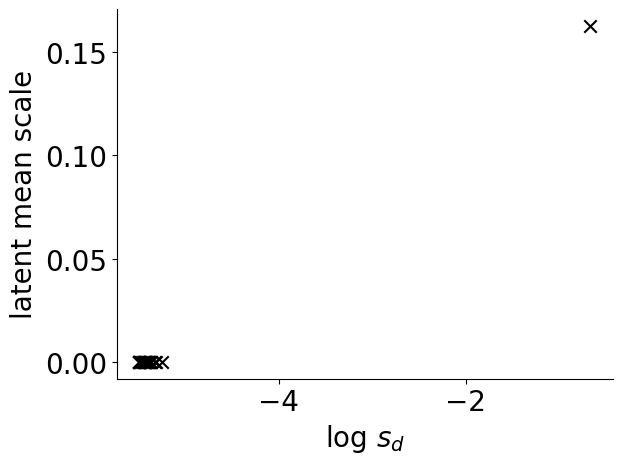

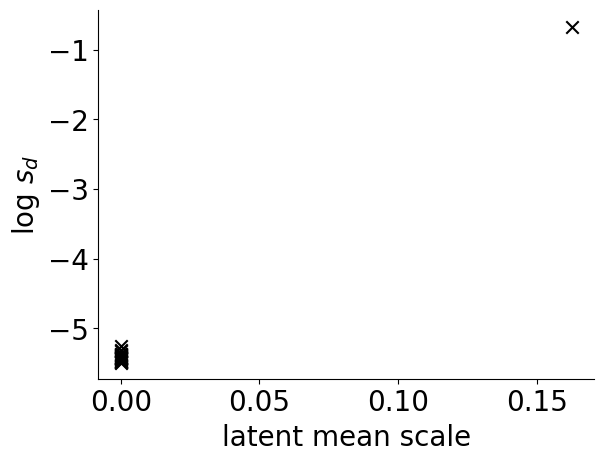

In [13]:
import pandas as pd
### we start by plotting 'informative' and 'discarded' dimensions ###
print('plotting informative and discarded dimensions')
dim_scales = mod.obs.dim_scale.detach().cpu().numpy().flatten() #prior scales (s_d)
dim_scales = np.log(dim_scales) #take the log of the prior scales
nus = np.sqrt(np.mean(mod.lat_dist.nu.detach().cpu().numpy()**2, axis = (0, -1))) #magnitude of the variational mean

# Create a DataFrame
df = pd.DataFrame({
    "nus": nus,
    "dim_scales": dim_scales
})

# Save to CSV
df.to_csv("scale_factors_OUT.csv", index=False)

plt.figure()
plt.scatter(dim_scales, nus, c = 'k', marker = 'x', s = 80) #top right corner are informative, lower left discarded
plt.xlabel(r'$\log \, s_d$')
plt.ylabel('latent mean scale', labelpad = 5)
plt.show()

plt.figure()
plt.scatter(nus,dim_scales,  c = 'k', marker = 'x', s = 80)
plt.ylabel(r'$\log \, s_d$')
plt.xlabel('latent mean scale', labelpad = 5)
plt.show()

plotting latent trajectories
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]


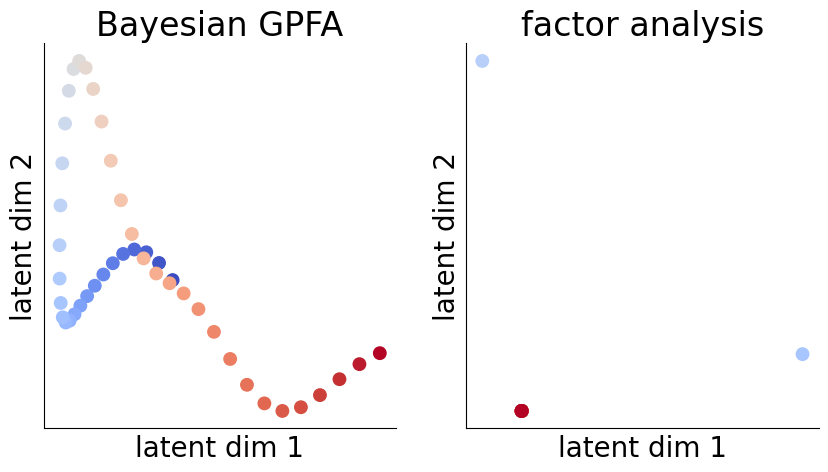

learned timescales (ms): [3504  296  229  240  291  311  182  267  404  152  254  299  261  222
  290  302  361  144  255  403  417  266  280  336  311]


In [14]:
### plot the inferred latent trajectories
print('plotting latent trajectories')
X = mod.lat_dist.lat_mu.detach().cpu().numpy()[0, ...] # extract inferred latents ('mu' has shape (ntrials x T x d_fit))
X = X[..., np.argsort(-dim_scales)] # only consider the two most informative dimensions (c.f. Jensen & Kao)


tplot = np.arange(0, 44) # let's only plot a shorter period (here 2.s) so it doesn't get too cluttered

print(tplot)

# fit FA for comparison
fa = FactorAnalysis(2)
Xfa = fa.fit_transform((Y[0, ...].T)) # sqrt the counts for variance stabilization (c.f. Yu et al. 2009)
#np.sqrt
i1, i2 = 0, 1 # which dimensions to plot
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].scatter(X[tplot, i1], X[tplot, i2], c = tplot, cmap = 'coolwarm', s = 80) # plot bGPFA latents
axs[1].scatter(Xfa[tplot, 0], Xfa[tplot, 1], c = tplot, cmap = 'coolwarm', s = 80) # plot FA latents
for ax in axs:
    ax.set_xlabel('latent dim 1')
    ax.set_ylabel('latent dim 2')
    ax.set_xticks([])
    ax.set_yticks([])
axs[0].set_title('Bayesian GPFA')
axs[1].set_title('factor analysis')
plt.show()

# let's also print the learned timescales (sorted by the prior scales s_d)
taus = mod.lat_dist.ell.detach().cpu().numpy().flatten()[np.argsort(-dim_scales)]*binsize
print('learned timescales (ms):', np.round(taus).astype(int))

In [15]:
import pandas as pd
# 2. Convert to a DataFrame and save
df = pd.DataFrame(X)
df.to_csv("output_GPFA_OUT.csv", index=False) 
# index=False prevents it from saving row numbers